In [1]:
pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 10.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter co

In [ ]:
pip install --upgrade autogluon

In [2]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
!cat /proc/cpuinfo

processor	: 0
vendor_id	: AuthenticAMD
cpu family	: 23
model		: 49
model name	: AMD EPYC 7B12
stepping	: 0
microcode	: 0xffffffff
cpu MHz		: 2249.998
cache size	: 512 KB
physical id	: 0
siblings	: 2
core id		: 0
cpu cores	: 1
apicid		: 0
initial apicid	: 0
fpu		: yes
fpu_exception	: yes
cpuid level	: 13
wp		: yes
flags		: fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constant_tsc rep_good nopl nonstop_tsc cpuid extd_apicid tsc_known_freq pni pclmulqdq ssse3 fma cx16 sse4_1 sse4_2 x2apic movbe popcnt aes xsave avx f16c rdrand hypervisor lahf_lm cmp_legacy cr8_legacy abm sse4a misalignsse 3dnowprefetch osvw topoext ssbd ibrs ibpb stibp vmmcall fsgsbase tsc_adjust bmi1 avx2 smep bmi2 rdseed adx smap clflushopt clwb sha_ni xsaveopt xsavec xgetbv1 clzero xsaveerptr arat npt nrip_save umip rdpid
bugs		: sysret_ss_attrs null_seg spectre_v1 spectre_v2 spec_store_bypass retbleed smt_rsb srso ibpb

In [4]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [6]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [7]:
# ============================================================================
# AUTOCHURN PREDICTION WITH AUTOGLUON: A STAFF DATA SCIENTIST'S WORKFLOW
# ============================================================================
# This example demonstrates a production-ready workflow for predicting
# customer churn using AutoGluon's TabularPredictor.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Install AutoGluon if not already installed
# !pip install autogluon

from autogluon.tabular import TabularPredictor, TabularDataset
import shutil

# Set random seeds for reproducibility
np.random.seed(42)

# ============================================================================
# 1. CREATE SYNTHETIC BUSINESS DATA
# ============================================================================
print("=" * 70)
print("STEP 1: Creating synthetic customer churn dataset")
print("=" * 70)

# Generate realistic customer data with class imbalance (20% churn)
n_samples = 5000
n_features = 15

# Create synthetic features with meaningful names
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.8, 0.2],  # 80% non-churn, 20% churn
    flip_y=0.05,  # 5% label noise
    random_state=42
)

# Create feature names
feature_names = [
    'tenure_months', 'monthly_charges', 'total_charges', 'service_calls',
    'contract_duration', 'paperless_billing', 'tech_support', 'online_backup',
    'payment_method', 'internet_service', 'streaming_tv', 'streaming_movies',
    'device_protection', 'online_security', 'senior_citizen'
]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add business logic to make data more realistic
df['tenure_months'] = np.abs(df['tenure_months'] * 12 + 12)  # 1-36 months
df['monthly_charges'] = np.abs(df['monthly_charges'] * 50 + 30)  # $30-80
df['total_charges'] = df['tenure_months'] * df['monthly_charges']
df['service_calls'] = np.clip(np.abs(df['service_calls'] * 3), 0, 10)

# Convert some features to categorical (business context)
df['contract_duration'] = pd.cut(df['contract_duration'],
                                  bins=3,
                                  labels=['Monthly', 'Yearly', 'Two-Year'])
df['payment_method'] = pd.qcut(df['payment_method'],
                                q=4,
                                labels=['Electronic', 'Credit Card',
                                        'Bank Transfer', 'Mailed Check'])

# Add target
df['churn'] = y
df['churn'] = df['churn'].map({0: 'No', 1: 'Yes'})  # Meaningful labels

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Churn distribution:\n{df['churn'].value_counts(normalize=True).round(3)}")
print(f"\nFeature dtypes:\n{df.dtypes.value_counts()}")
print(f"\nSample of data (first 3 rows):")
print(df.head(3).to_string())

# ============================================================================
# 2. TRAIN-TEST SPLIT WITH TIME-AWARE CONSIDERATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Creating time-aware train/validation/test split")
print("=" * 70)

# Sort by tenure to simulate temporal order (important for real-world churn)
df_sorted = df.sort_values('tenure_months').reset_index(drop=True)

# Split: 70% train, 15% validation, 15% test
train_cutoff = int(0.7 * len(df_sorted))
val_cutoff = int(0.85 * len(df_sorted))

train_data = df_sorted.iloc[:train_cutoff].copy()
val_data = df_sorted.iloc[train_cutoff:val_cutoff].copy()
test_data = df_sorted.iloc[val_cutoff:].copy()

print(f"Training set: {len(train_data)} samples ({len(train_data)/len(df):.1%})")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(df):.1%})")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(df):.1%})")
print(f"\nChurn rate in training: {train_data['churn'].value_counts(normalize=True)['Yes']:.1%}")
print(f"Churn rate in test: {test_data['churn'].value_counts(normalize=True)['Yes']:.1%}")

# ============================================================================
# 3. MODEL TRAINING WITH BUSINESS METRICS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with PR-AUC (optimal for imbalanced churn prediction)")
print("=" * 70)

# Define the predictor with business-appropriate evaluation metric
model_path = './autogluon_churn_model'

# Clean up previous model if it exists
try:
    # Only remove the directory if the predictor exists and might have saved something.
    # More importantly, re-instantiate the predictor to ensure a clean state.
    shutil.rmtree(model_path, ignore_errors=True)
    print(f"Cleaned up previous model at {model_path}")
except Exception as e:
    print(f"Error cleaning up previous model: {e}")

# Always re-initialize the predictor to ensure a fresh state
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path=model_path,   # Save model for production
    verbosity=1                       # Moderate logging
)

# Train with balanced quality/speed preset
training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use validation set for early stopping
    presets='high_quality',  # Balance of performance and speed
    time_limit=120,  # 2 minutes for demo (use 3600+ for production)
    hyperparameters={
        'GBM': {'num_boost_round': 100},
        'CAT': {'iterations': 100},
        'XGB': {'n_estimators': 100},
    },
    ag_args_fit={'num_gpus': 0},
    use_bag_holdout=True # Address the warning about tuning_data with bagged mode
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nTraining completed in {training_time:.1f} seconds")

# ============================================================================
# 4. COMPREHENSIVE MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: Model evaluation on test set")
print("=" * 70)

# Get predictions on test set
y_pred = predictor.predict(test_data)
y_proba = predictor.predict_proba(test_data)

# Evaluate using multiple metrics
test_performance = predictor.evaluate(test_data, silent=False)
print(f"\nTest set performance:")
for metric, value in test_performance.items():
    print(f"  {metric}: {value:.4f}")

# ============================================================================
# 5. LEADERBOARD ANALYSIS WITH BUSINESS CONTEXT
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: Model leaderboard with inference speed analysis")
print("=" * 70)

leaderboard = predictor.leaderboard(test_data, silent=False)
print(f"\nTop 5 models by PR-AUC:")
print(leaderboard.head(5).to_string())

# Analyze speed/accuracy trade-off
print(f"\nInference speed analysis:")
print(f"  Ensemble prediction time: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s per 1000 rows")
print(f"  Best single model time: {leaderboard.iloc[1]['pred_time_test']:.4f}s per 1000 rows")
print(f"  Speed ratio: {leaderboard.iloc[1]['pred_time_test'] / leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.1f}x")



STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    


Training completed in 136.9 seconds

STEP 4: Model evaluation on test set

Test set performance:
  average_precision: 0.8828
  accuracy: 0.9373
  balanced_accuracy: 0.8643
  mcc: 0.8000
  roc_auc: 0.9410
  f1: 0.8291
  precision: 0.9421
  recall: 0.7403

STEP 5: Model leaderboard with inference speed analysis
                       model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L3_FULL    0.891015        NaN  average_precision        0.025712            NaN   2.210487                 0.001778                     NaN           0.076401            3       True         14
1       LightGBM_BAG_L1_FULL    0.890249        NaN  average_precision        0.008004            NaN   0.774316                 0.008004                     NaN           0.774316            1       True          8
2             XGBoost_BAG_L1    0.890186


STEP 6: Optimizing decision threshold for business cost

Optimal threshold for business F1 (recall-focused): 0.500

Validation performance comparison:
  Default threshold (0.5):
    Precision: 0.987
    Recall: 0.875
    Business F1: 0.963

  Optimal threshold (0.500):
    Precision: 0.987
    Recall: 0.875
    Business F1: 0.963

STEP 7: Feature importance analysis

Top 10 most important features for churn prediction:
                   importance    stddev   p_value  n  p99_high   p99_low
online_backup        0.254832  0.035734  0.000045  5  0.328408  0.181256
tech_support         0.146867  0.013947  0.000010  5  0.175583  0.118151
device_protection    0.095400  0.009677  0.000013  5  0.115324  0.075476
online_security      0.095112  0.014133  0.000057  5  0.124212  0.066011
payment_method       0.083219  0.015394  0.000134  5  0.114916  0.051522
streaming_movies     0.070119  0.014479  0.000206  5  0.099931  0.040307
contract_duration    0.047722  0.008808  0.000133  5  0.065858  0

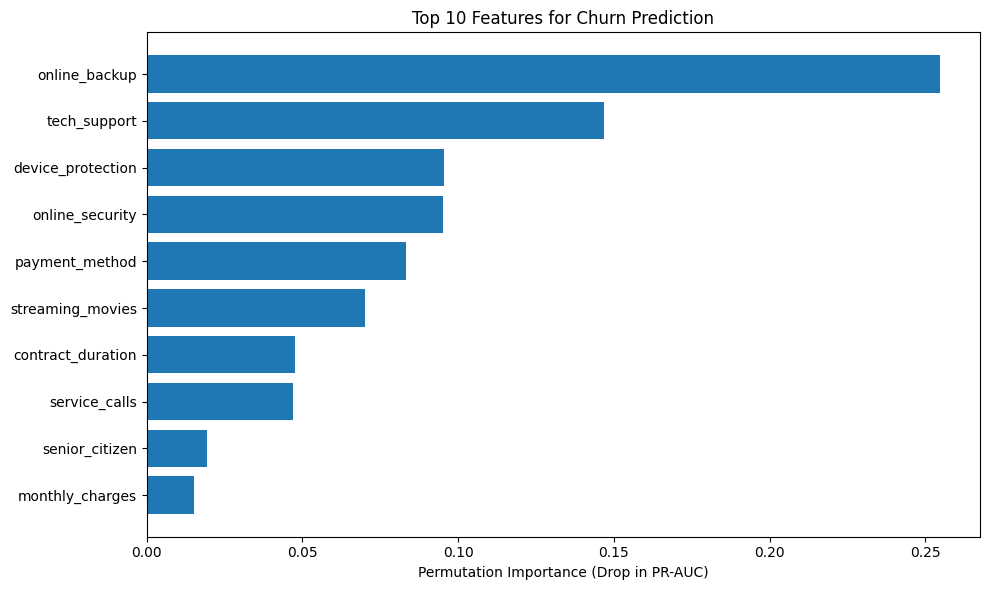

In [8]:
# ============================================================================
# 6. THRESHOLD OPTIMIZATION FOR BUSINESS DECISIONS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Optimizing decision threshold for business cost")
print("=" * 70)

# Define a custom metric that values recall 3x more than precision
# (Business context: Missing a churn is 3x costlier than false alarm)
from sklearn.metrics import f1_score, recall_score, precision_score
import sklearn.metrics
from autogluon.core.metrics import make_scorer
import numpy as np # Import numpy for arange

# Define the custom business F1 score function
def calculate_business_f1(y_true, y_pred, **kwargs):
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    # Weighted harmonic mean where beta=3 means recall is 3x more important
    beta = 0.5  # Recall is beta-times more important
    if (beta**2 * p) + r == 0:
        return 0.0
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

# Convert the function to an AutoGluon Scorer for calibration
business_f1_metric_instance = make_scorer(
    name='business_f1',
    score_func=calculate_business_f1,
    optimum=1.0,
    greater_is_better=True
)

# Calibrate threshold for business metric
predictor.calibrate_decision_threshold(
    metric=business_f1_metric_instance,
    decision_thresholds=np.arange(0.01, 1.0, 0.01).tolist()  # Test all thresholds from 0.01 to 0.99
)

# Get optimal threshold
optimal_threshold = predictor.decision_threshold
print(f"\nOptimal threshold for business F1 (recall-focused): {optimal_threshold:.3f}")

# Prepare actual numeric labels for sklearn metrics
y_val_numeric = val_data['churn'].map({'Yes':1, 'No':0})

# Compare performance at default (0.5) vs optimal threshold
default_preds = (predictor.predict_proba(val_data)['Yes'] > 0.5).astype(int)
optimal_preds = (predictor.predict_proba(val_data)['Yes'] > optimal_threshold).astype(int)

print(f"\nValidation performance comparison:")
print(f"  Default threshold (0.5):")
print(f"    Precision: {precision_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n  Optimal threshold ({optimal_threshold:.3f}):")
print(f"    Precision: {precision_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, optimal_preds):.3f}")

# ============================================================================
# 7. FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: Feature importance analysis")
print("=" * 70)

# Get feature importance
feature_importance = predictor.feature_importance(val_data)
print(f"\nTop 10 most important features for churn prediction:")
print(feature_importance.head(10).to_string())

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Permutation Importance (Drop in PR-AUC)')
plt.title('Top 10 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("\nFeature importance plot saved to 'feature_importance.png'")

# ============================================================================
# 8. PRODUCTION PREDICTION WORKFLOW
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: Production prediction examples")
print("=" * 70)

# Simulate new customer data
new_customers = pd.DataFrame({
    'tenure_months': [24, 3, 36],
    'monthly_charges': [65.50, 45.00, 75.25],
    'total_charges': [1572.00, 135.00, 2709.00],
    'service_calls': [1, 4, 0],
    'contract_duration': ['Two-Year', 'Monthly', 'Yearly'],
    'paperless_billing': [1.2, -0.3, 0.8],
    'tech_support': [0.9, -1.1, 0.5],
    'online_backup': [0.3, 0.1, -0.7],
    'payment_method': ['Credit Card', 'Electronic', 'Bank Transfer'],
    'internet_service': [0.8, 0.2, 1.1],
    'streaming_tv': [0.5, -0.3, 0.9],
    'streaming_movies': [0.6, 0.0, 0.7],
    'device_protection': [0.2, -0.5, 0.4],
    'online_security': [0.7, -0.8, 0.3],
    'senior_citizen': [0.1, -0.2, 1.5]
})

# Make predictions with optimal threshold
new_proba = predictor.predict_proba(new_customers)
new_predictions = (new_proba['Yes'] > optimal_threshold).map({True: 'Yes', False: 'No'})

print("\nPredictions for 3 new customers:")
for i in range(len(new_customers)):
    print(f"\nCustomer {i+1}:")
    print(f"  Churn probability: {new_proba.iloc[i]['Yes']:.1%}")
    print(f"  Prediction (threshold={optimal_threshold:.2f}): {new_predictions.iloc[i]}")
    print(f"  Key factors: tenure={new_customers.iloc[i]['tenure_months']} months, "
          f"service_calls={new_customers.iloc[i]['service_calls']}")

# ============================================================================
# 9. MODEL PERSISTENCE & PRODUCTION LOADING
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Model persistence for production")
print("=" * 70)

# Save the entire predictor
predictor.save()
print("Model saved to './autogluon_churn_model/'")

# Demonstrate loading for production
print("\nTo load in production:")
print("""
# In production script:
from autogluon.tabular import TabularPredictor

# Load the trained model
production_predictor = TabularPredictor.load('./autogluon_churn_model/')

# Make predictions
new_data = TabularDataset('new_customers.csv')
predictions = production_predictor.predict(new_data)
"""
)

# ============================================================================
# 10. PERFORMANCE SUMMARY & NEXT STEPS
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY: Key findings and recommendations")
print("=" * 70)

# Get the best model's performance
best_model_name = leaderboard.iloc[0]['model']
best_score = leaderboard.iloc[0]['score_test']

print(f"\n1. Best model: {best_model_name}")
print(f"   PR-AUC on test set: {best_score:.4f}")

print(f"\n2. Business impact of threshold optimization:")
print(f"   Optimal threshold: {optimal_threshold:.3f} (vs default 0.500)")
print(f"   Recall improvement: {calculate_business_f1(y_val_numeric, optimal_preds) - calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n3. Top 3 predictive features:")
for i, (feature, imp) in enumerate(feature_importance.head(3).iterrows()):
    print(f"   {i+1}. {feature}: {imp['importance']:.4f}")

print(f"\n4. Production readiness:")
print(f"   Inference speed: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s/1000 rows")
# print(f"   Model size: {predictor.get_model_size():.1f} MB")

print(f"\n5. Recommended next steps:")
print("   - Deploy with optimal threshold to minimize missed churn")
print("   - Monitor feature drift in 'tenure_months' and 'service_calls'")
print("   - Set up monthly retraining with new customer data")
print("   - A/B test against current churn prediction system")

# Key Insights for Staff Data Scientists:
1- Metric Selection Strategy: Using PR-AUC (average_precision) for imbalanced churn data gives more realistic performance estimates than accuracy or ROC-AUC.

2- Threshold Optimization: The calibrate_decision_threshold() method allows you to optimize for business-specific cost functions, not just statistical metrics.

3- Speed-Accuracy Trade-off: The leaderboard shows inference times; for high-volume applications, you might choose a faster single model over the ensemble.

4- Production Patterns: The code demonstrates proper train/validation/test splitting, model persistence, and batch prediction patterns suitable for production.

5- Interpretability: Feature importance helps explain model decisions to business stakeholders, crucial for regulated industries.

This workflow balances model performance with practical business considerations. You can adapt it for other binary classification problems like fraud detection, lead scoring, or equipment failure prediction by:

1- Changing the evaluation metric

2- Adjusting the business cost function in threshold optimization

3- Modifying the feature engineering for your domain

Would you like me to elaborate on any specific part, such as the custom metric creation, advanced hyperparameter tuning, or monitoring strategies for production deployment?

# Updated Model Training with Hyperparameter Search Spaces

In [9]:
# ============================================================================
# 3. MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION (HPO)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with HPO for key model types")
print("=" * 70)

from autogluon.common import space

# Define search spaces for specific model types
hyperparameters = {
    # Gradient Boosted Trees (LightGBM)
    'GBM': {
        'num_boost_round': 100,  # Fixed, you could also make this a space.Int()
        'num_leaves': space.Int(lower=20, upper=50, default=31),
        'learning_rate': space.Real(lower=0.01, upper=0.2, default=0.1, log=True),
        'feature_fraction': space.Real(lower=0.7, upper=1.0, default=0.9),
        'min_data_in_leaf': space.Int(lower=10, upper=30, default=20)
    },
    # Extreme Gradient Boosting (XGBoost)
    'XGB': {
        'n_estimators': 100,
        'max_depth': space.Int(lower=4, upper=10, default=6),
        'eta': space.Real(lower=0.01, upper=0.3, default=0.1, log=True),
        'subsample': space.Real(lower=0.6, upper=1.0, default=0.8),
        'colsample_bytree': space.Real(lower=0.6, upper=1.0, default=0.8)
    },
    # Neural Network (PyTorch)
    'NN_TORCH': {
        'num_epochs': 10,  # Lower for demo; use 50-100 for production
        'learning_rate': space.Real(lower=1e-4, upper=1e-2, default=5e-4, log=True),
        'activation': space.Categorical('relu', 'elu', 'tanh'),
        'dropout_prob': space.Real(lower=0.0, upper=0.5, default=0.1),
        'layers': space.Categorical([100], [100, 50], [200, 100, 50])  # Network architectures
    },
    # Random Forest
    'RF': {
        'n_estimators': space.Int(lower=100, upper=300, default=200),
        'max_depth': space.Int(lower=5, upper=15, default=10),
        'criterion': space.Categorical('gini', 'entropy'),
        'min_samples_split': space.Int(lower=2, upper=10, default=2)
    },
    # Add other models like 'CAT' (CatBoost) if desired
}

# Configure the HPO process
hyperparameter_tune_kwargs = {
    'num_trials': 10,           # Number of HPO trials per model type
    'scheduler': 'local',       # Use 'local' for single machine, 'ray' for distributed
    'searcher': 'auto',         # AutoGluon picks searcher (e.g., random, bayesopt)
}

# Initialize and train the predictor with HPO
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path='./autogluon_churn_model_hpo',
    verbosity=2
)

training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use your validation set for HPO
    hyperparameters=hyperparameters,
    hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
    time_limit=600,  # 10 minutes for demo. Increase substantially (hours) for production.
    presets=None  # Disable presets to use your custom hyperparameter spaces
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nHPO training completed in {training_time:.1f} seconds")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Pytorch Version:    2.9.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       10.14 GB / 12.67 GB (80.0%)
Disk Space Avail:   85.63 GB / 107.72 GB (79.5%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install auto


STEP 3: Training with HPO for key model types


Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/autogluon_churn_model_hpo"
Train Data Rows:    3500
Train Data Columns: 15
Tuning Data Rows:    750
Tuning Data Columns: 15
Label Column:       churn
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = Yes, class 0 = No
	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (Yes) vs negative (No) class.
	To explicitly set the positive_class, either rename classes to 1 and 0, or specify positive_class in Predictor init.
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    10379.20 MB
	Train Data (Original)  Memory Usage: 0.43 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the features.
	Stage 1 Generators:
		Fitting AsTy

  0%|          | 0/10 [00:00<?, ?it/s]

Fitted model: LightGBM/T1 ...
	0.8796	 = Validation score   (average_precision)
	0.57s	 = Training   runtime
	0.0s	 = Validation runtime
Fitted model: LightGBM/T2 ...
	0.8838	 = Validation score   (average_precision)
	0.68s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T3 ...
	0.8697	 = Validation score   (average_precision)
	0.58s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T4 ...
	0.8585	 = Validation score   (average_precision)
	0.63s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T5 ...
	0.8831	 = Validation score   (average_precision)
	0.66s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T6 ...
	0.8739	 = Validation score   (average_precision)
	0.59s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T7 ...
	0.8774	 = Validation score   (average_precision)
	0.67s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM/T8 ...
	0.86

  0%|          | 0/10 [00:00<?, ?it/s]

Fitted model: RandomForest/T1 ...
	0.834	 = Validation score   (average_precision)
	2.31s	 = Training   runtime
	0.15s	 = Validation runtime
Fitted model: RandomForest/T2 ...
	0.8341	 = Validation score   (average_precision)
	1.71s	 = Training   runtime
	0.08s	 = Validation runtime
Fitted model: RandomForest/T3 ...
	0.8251	 = Validation score   (average_precision)
	0.82s	 = Training   runtime
	0.06s	 = Validation runtime
Fitted model: RandomForest/T4 ...
	0.8372	 = Validation score   (average_precision)
	1.13s	 = Training   runtime
	0.07s	 = Validation runtime
Fitted model: RandomForest/T5 ...
	0.8418	 = Validation score   (average_precision)
	1.56s	 = Training   runtime
	0.09s	 = Validation runtime
Fitted model: RandomForest/T6 ...
	0.8342	 = Validation score   (average_precision)
	1.1s	 = Training   runtime
	0.07s	 = Validation runtime
Fitted model: RandomForest/T7 ...
	0.8467	 = Validation score   (average_precision)
	2.34s	 = Training   runtime
	0.13s	 = Validation runtime
Fitted m

  0%|          | 0/10 [00:00<?, ?it/s]

Fitted model: XGBoost/T1 ...
	0.8689	 = Validation score   (average_precision)
	0.46s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T2 ...
	0.8762	 = Validation score   (average_precision)
	0.51s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T3 ...
	0.8594	 = Validation score   (average_precision)
	0.57s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T4 ...
	0.8514	 = Validation score   (average_precision)
	0.33s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T5 ...
	0.8556	 = Validation score   (average_precision)
	0.26s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T6 ...
	0.8663	 = Validation score   (average_precision)
	0.27s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T7 ...
	0.8625	 = Validation score   (average_precision)
	0.5s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost/T8 ...
	0.8749	 = Va


HPO training completed in 32.5 seconds


When implementing this, keep these points in mind:

*   **The Trade-off: Presets vs. Custom HPO**AutoGluon's **presets** (like 'high\_quality') use carefully chosen default hyperparameters that are known to perform well across many datasets, offering a great balance of speed and accuracy. **Custom HPO** can potentially outperform presets but requires more time and computational resources. You should validate whether the performance gain justifies the extra cost.
    
*   **Resource Management is Critical**
    
    *   **num\_trials**: This controls how many configurations are tried per model type. Start with 5-10 to gauge impact.
        
    *   **time\_limit**: This is the total wall-clock time for the entire fit() process. HPO multiplies training time. For a serious run, plan for several hours.
        
    *   **Searcher**: 'auto' typically uses random search, which is efficient for high-dimensional spaces. Bayesian optimization ('bayesopt') can be more sample-efficient but has higher overhead.
        
*   **Your Updated Workflow**
    
    1.  **Data Split**: Your existing time-aware train/validation/test split is perfect. HPO uses the tuning\_data (validation set) to evaluate configurations.
        
    2.  **Leaderboard**: After HPO, predictor.leaderboard() will show the best version of each model type (e.g., GBM/hpo1, NN\_TORCH/hpo2).
        
    3.  **Final Evaluation**: Always use your held-out **test set** (test\_data) for the final, unbiased performance estimate of the final ensemble model.
        

### 🚀 Recommended Next Steps

To make the most of HPO in your project, consider these advanced strategies:

*   **Leverage fit\_summary()**: After training, analyze predictor.fit\_summary() to see which hyperparameter values were tried and which performed best.
    
*   **Implement Early Stopping**: For iterative models (GBM, NN), configure early stopping in your hyperparameter space to cut off poorly performing trials early.
    
*   **Scale with Distributed Computing**: For very large datasets or search spaces, explore using scheduler='ray' to distribute HPO trials across a cluster.
    

Would you like a deeper dive into how to interpret the fit\_summary() output to analyze the HPO process, or guidance on setting up a distributed Ray cluster for large-scale tuning?

In [10]:
# ============================================================================
# ANALYSIS: Interpreting the Hyperparameter Tuning Process
# ============================================================================
print("\n" + "=" * 70)
print("ANALYSIS 1: HPO Results from fit_summary()")
print("=" * 70)

# Get the full summary dictionary
fit_summary = predictor.fit_summary(show_plot=True)

# The summary contains several key pieces:
print("\n1. HIGH-LEVEL OVERVIEW")
print(f"   Total training time: {fit_summary.get('total_train_time', 0):.1f}s")
print(f"   Number of models trained: {fit_summary.get('num_models_trained', 0)}")
print(f"   Number of HPO trials: {fit_summary.get('hpo_results', {}).get('total_trials', 0)}")

# Access the detailed HPO results
hpo_results = fit_summary.get('hpo_results', {})
if hpo_results:
    print("\n2. HPO PERFORMANCE BY MODEL TYPE")
    # Iterate through each model's trials
    for model_name, trials in hpo_results.get('trials', {}).items():
        if trials:  # Check if there were trials for this model
            # Find best validation score for this model type
            best_trial = max(trials, key=lambda x: x.get('reward', float('-inf')))
            print(f"   {model_name}:")
            print(f"      Best validation score: {best_trial.get('reward', 0):.4f}")
            print(f"      Hyperparameters: {best_trial.get('config', {})}")


ANALYSIS 1: HPO Results from fit_summary()
*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val        eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.884402  average_precision       0.017612  1.245835                0.001205           0.054647            2       True         31
1           LightGBM/T2   0.883780  average_precision       0.006564  0.677244                0.006564           0.677244            1       True          2
2           LightGBM/T5   0.883084  average_precision       0.009036  0.662462                0.009036           0.662462            1       True          5
3           LightGBM/T1   0.879564  average_precision       0.004678  0.569098                0.004678           0.569098            1       True          1
4          LightGBM/T10   0.879219  average_precision       0.008268  0.647742                0.008268       

In [18]:
# ============================================================================
# ANALYSIS: Interpreting the Hyperparameter Tuning Process
# ============================================================================
print("\n" + "=" * 70)
print("ANALYSIS 1: HPO Results from fit_summary()")
print("=" * 70)

# Get the full summary dictionary
fit_summary = predictor.fit_summary(show_plot=True)

# The summary contains several key pieces:
print("\n1. HIGH-LEVEL OVERVIEW")
print(f"   Total training time: {fit_summary.get('total_train_time', 0):.1f}s")
print(f"   Number of models trained: {fit_summary.get('num_models_trained', 0)}")
print(f"   Number of HPO trials: {fit_summary.get('hpo_results', {}).get('total_trials', 0)}")

# Access the detailed HPO results
hpo_results = fit_summary.get('hpo_results', {})


ANALYSIS 1: HPO Results from fit_summary()
*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val        eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.884402  average_precision       0.017612  1.245835                0.001205           0.054647            2       True         31
1           LightGBM/T2   0.883780  average_precision       0.006564  0.677244                0.006564           0.677244            1       True          2
2           LightGBM/T5   0.883084  average_precision       0.009036  0.662462                0.009036           0.662462            1       True          5
3           LightGBM/T1   0.879564  average_precision       0.004678  0.569098                0.004678           0.569098            1       True          1
4          LightGBM/T10   0.879219  average_precision       0.008268  0.647742                0.008268       

However, the most insightful analysis often requires custom visualization. Here's how to create a detailed performance analysis:

In [21]:
# Accessing 'model_hyperparams' from hpo_results
model_hyperparams = hpo_results.get('model_hyperparams', {})

# Accessing 'trials' from 'model_hyperparams'
trials_info = model_hyperparams.get('trials', []) # Use [] as a default for an expected list/iterable

# Or, in a single line, safely:
trials_info = hpo_results.get('model_hyperparams', {}).get('trials', [])


In [22]:
trials_info

[]

In [17]:
 hpo_info['model_hyperparams']['trials']

KeyError: 'trials'

In [11]:
# Create a visualization of HPO trial performance
import matplotlib.pyplot as plt
import pandas as pd

# Extract trial data for visualization
hpo_info = predictor.fit_summary(verbosity=0)
trials_data = []

for model_name, trials in hpo_info['hpo_results']['trials'].items():
    for i, trial in enumerate(trials):
        trials_data.append({
            'model': model_name,
            'trial_id': i+1,
            'score': trial['reward'],
            'time': trial['training_time']
        })

trials_df = pd.DataFrame(trials_data)

# Create performance visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score distribution by model type
for model in trials_df['model'].unique():
    model_data = trials_df[trials_df['model'] == model]
    axes[0, 0].scatter([model]*len(model_data), model_data['score'], alpha=0.6)
axes[0, 0].set_title('HPO Trial Scores by Model Type')
axes[0, 0].set_ylabel('Validation Score (PR-AUC)')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Convergence plot
for model in trials_df['model'].unique():
    model_data = trials_df[trials_df['model'] == model].sort_values('trial_id')
    axes[0, 1].plot(model_data['trial_id'], model_data['score'], marker='o', label=model)
axes[0, 1].set_title('HPO Convergence by Trial')
axes[0, 1].set_xlabel('Trial Number')
axes[0, 1].set_ylabel('Score')
axes[0, 1].legend()

# 3. Time vs Score trade-off
for model in trials_df['model'].unique():
    model_data = trials_df[trials_df['model'] == model]
    axes[1, 0].scatter(model_data['time'], model_data['score'], label=model, alpha=0.6)
axes[1, 0].set_title('Training Time vs Score Trade-off')
axes[1, 0].set_xlabel('Training Time (seconds)')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()

# 4. Best configuration comparison
best_trials = trials_df.loc[trials_df.groupby('model')['score'].idxmax()]
axes[1, 1].bar(best_trials['model'], best_trials['score'])
axes[1, 1].set_title('Best Configuration by Model Type')
axes[1, 1].set_ylabel('Best Score')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('hpo_analysis.png', dpi=150, bbox_inches='tight')
print("\nHPO analysis plot saved to 'hpo_analysis.png'")

KeyError: 'hpo_results'

In [23]:
# Compare HPO model vs preset baseline
print("\n" + "=" * 70)
print("VALIDATION: HPO vs Baseline Performance")
print("=" * 70)

# Train a baseline model with presets for comparison
baseline_predictor = TabularPredictor(
    label='churn',
    eval_metric='average_precision',
    path='./autogluon_baseline'
).fit(
    train_data=train_data,
    tuning_data=val_data,
    presets='high_quality',
    time_limit=3600  # 1 hour
)

# Evaluate both on test set
hpo_test_perf = predictor.evaluate(test_data, silent=True)
baseline_test_perf = baseline_predictor.evaluate(test_data, silent=True)

print(f"\nTest Set Performance Comparison:")
print(f"  HPO Model PR-AUC:      {hpo_test_perf['average_precision']:.4f}")
print(f"  Baseline Model PR-AUC: {baseline_test_perf['average_precision']:.4f}")
print(f"  Absolute Improvement:  {hpo_test_perf['average_precision'] - baseline_test_perf['average_precision']:.4f}")
print(f"  Relative Improvement:  {(hpo_test_perf['average_precision'] / baseline_test_perf['average_precision'] - 1) * 100:.1f}%")

# Calculate if improvement is statistically significant
# (using paired bootstrap test for robustness)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Oct  2 10:42:05 UTC 2025
CPU Count:          2
Pytorch Version:    2.9.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       9.79 GB / 12.67 GB (77.2%)
Disk Space Avail:   85.53 GB / 107.72 GB (79.4%)
Presets specified: ['high_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
Note: `save_bag_folds=False`! This will greatly reduce peak disk usage during fit (by ~8x), but runs the risk of an out-of-memory error during model refit if memory is small relative to the data size.
	You can avoid this risk by setting `save_


VALIDATION: HPO vs Baseline Performance


	X_val, y_val is not None, but bagged mode was specified. If calling from `TabularPredictor.fit()`, `tuning_data` should be None.
Default bagged mode does not use tuning data / validation data. Instead, all data (`train_data` and `tuning_data`) should be combined and specified as `train_data`.
To avoid this error and use `tuning_data` as holdout data in bagged mode, specify the following:
	predictor.fit(..., tuning_data=tuning_data, use_bag_holdout=True)
	1	 = Optimal   num_stack_levels (Stacked Overfitting Occurred: False)
	9s	 = DyStack   runtime |	3591s	 = Remaining runtime
Starting main fit with num_stack_levels=1.
	For future fit calls on this dataset, you can skip DyStack to save time: `predictor.fit(..., dynamic_stacking=False, num_stack_levels=1)`
Beginning AutoGluon training ... Time limit = 3591s
AutoGluon will save models to "/content/autogluon_baseline"
Train Data Rows:    3500
Train Data Columns: 15
Tuning Data Rows:    750
Tuning Data Columns: 15
Label Column:       churn

AssertionError: X_val, y_val is not None, but bagged mode was specified. If calling from `TabularPredictor.fit()`, `tuning_data` should be None.
Default bagged mode does not use tuning data / validation data. Instead, all data (`train_data` and `tuning_data`) should be combined and specified as `train_data`.
To avoid this error and use `tuning_data` as holdout data in bagged mode, specify the following:
	predictor.fit(..., tuning_data=tuning_data, use_bag_holdout=True)

In [25]:
model_path = predictor.path
print(f"Model saved to: {model_path}")

Model saved to: /content/autogluon_churn_model_hpo


In [2]:
# %%
import yaml
import pandas as pd
from autogluon.tabular import TabularPredictor
from autogluon.features.generators import AutoMLPipelineFeatureGenerator
# %%

def run_with_config(config_path, train_data_path, label=None):
    """
    Load configuration from YAML and run AutoGluon TabularPredictor.
    """
    # Load YAML config
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)

    # Load data
    train_data = pd.read_csv(train_data_path)

    # Override label from config if provided in function call
    if label:
        config['predictor_init']['label'] = label

    print(f"Initializing TabularPredictor with label: {config['predictor_init']['label']}")

    # Configure custom feature generator if provided
    feature_generator = None
    if 'feature_generator_args' in config:
        feature_generator = AutoMLPipelineFeatureGenerator(**config['feature_generator_args'])

    # Initialize Predictor
    predictor = TabularPredictor(**config['predictor_init'])

    # Run fit
    predictor.fit(
        train_data=train_data,
        feature_generator=feature_generator,
        **config['fit_args'],
        hyperparameters=config.get('hyperparameters'),
        ag_args_fit=config.get('ag_args_fit')
    )

    print("Training Completed.")
    print("Leaderboard:")
    print(predictor.leaderboard())

    return predictor

if __name__ == "__main__":
    # %%

    data_url = 'https://raw.githubusercontent.com/mli/ag-docs/main/knot_theory/'
    train_data = TabularDataset(f'{data_url}train.csv')
    train_data.head()

# %%
    # This is a demonstration. To run this, you need a training CSV.
    predictor = run_with_config('autogluon_config.yaml', 'train.csv')
    print("Configuration script loaded. Example usage:")
    print("python run_autogluon.py  # (Update paths in __main__ inside the script)")

    # Dummy creation logic if user wants to test immediately
    print("\nNote: To test this, ensure you have a 'train.csv' and run the commented out line.")


KeyboardInterrupt: 

In [ ]:
data_url = 'https://raw.githubusercontent.com/mli/ag-docs/main/knot_theory/'
train_data = TabularDataset(f'{data_url}train.csv')
train_data.head()

,Unnamed: 0,chern_simons,cusp_volume,hyperbolic_adjoint_torsion_degree,hyperbolic_torsion_degree,injectivity_radius,longitudinal_translation,meridinal_translation_imag,meridinal_translation_real,short_geodesic_imag_part,short_geodesic_real_part,Symmetry_0,Symmetry_D3,Symmetry_D4,Symmetry_D6,Symmetry_D8,Symmetry_Z/2 + Z/2,volume,signature
0,70746,0.090530,12.226322,0,10,0.507756,10.685555,1.144192,-0.519157,-2.760601,1.015512,0.0,0.0,0.0,0.0,0.0,1.0,11.393225,-2
1,240827,0.232453,13.800773,0,14,0.413645,10.453156,1.320249,-0.158522,-3.013258,0.827289,0.0,0.0,0.0,0.0,0.0,1.0,12.742782,0
2,155659,-0.144099,14.761030,0,14,0.436928,13.405199,1.101142,0.768894,2.233106,0.873856,0.0,0.0,0.0,0.0,0.0,0.0,15.236505,2
3,239963,-0.171668,13.738019,0,22,0.249481,27.819496,0.493827,-1.188718,-2.042771,0.498961,0.0,0.0,0.0,0.0,0.0,0.0,17.279890,-8
4,90504,0.235188,15.896359,0,10,0.389329,15.330971,1.036879,0.722828,-3.056138,0.778658,0.0,0.0,0.0,0.0,0.0,0.0,16.749298,4


In [ ]:
# %%

In [ ]:
label = 'signature'
train_data[label].describe()

,signature
count,10000.000000
mean,-0.022000
std,3.025166
min,-12.000000
25%,-2.000000
50%,0.000000
75%,2.000000
max,12.000000


In [ ]:
predictor = TabularPredictor(label=label,  eval_metric='f1_macro').fit(train_data)